# Validating the merged-clock EMA against own-clock EMAs

A direct test of the `docs/ema_event_clock.md` design. Claim: a per-exchange flow
EMA computed on the **merged trade clock** at a large window N reproduces the same
exchange's EMA computed on its **own** trade clock at the window `N_ex` that spans
the same average wall-clock time — *despite* the per-exchange decay varying tick
to tick on the merged clock. We then watch the agreement loosen as N shrinks.

**Procedure**
1. Build the merged eth_usdt_p trade stream (bin+byb+okx, ordered by `rx_time`).
   For a large `N` (=20000), measure the mean wall-clock duration `D` of an
   N-trade merged window.
2. For each exchange, tune `N_ex` on its *own* trade stream so its mean N_ex-trade
   window duration ≈ `D`.
3. Compute the exchange's **trade-volume EMA** two ways and compare:
   - **merged clock, N**: the design's debiased average `E/W` (§4) — `E` and `W`
     are constant-decay filters on the merged stream, so this is just
     `lfilter(E)/lfilter(W)` sampled at the exchange's trades.
   - **own clock, N_ex**: a plain constant-α EMA on the exchange's own trades.
4. Repeat for small N (1000, 100) to see where the approximation frays.

`E/W` is the apples-to-apples match to a per-trade own-clock EMA (both are
"average trade volume"); the raw intensity `E` would carry the rate factor.

In [1]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from scipy.signal import lfilter
from boba.io import load_block, list_blocks

COIN = "eth_usdt_p"
EX = ["bin", "byb", "okx"]
NS = [20000, 1000, 100]
BLOCK = list_blocks(f"bin_{COIN}", "trade")[0]
print("block:", BLOCK)

block: holocron.20260520T135822.0


## Build the merged trade stream

In [2]:
def load_ex(ex):
    td = (load_block(BLOCK, f"{ex}_{COIN}", "trade").select("rx_time", "prc", "qty")
          .filter((pl.col("prc") > 0) & (pl.col("qty") > 0)).sort("rx_time"))   # drop bin zero-prints
    return td["rx_time"].cast(pl.Int64).to_numpy(), td["qty"].to_numpy()

rxs, qtys, eids = [], [], []
for k, ex in enumerate(EX):
    rx, qty = load_ex(ex)
    rxs.append(rx); qtys.append(qty); eids.append(np.full(len(rx), k))
mrx = np.concatenate(rxs); mqty = np.concatenate(qtys); meid = np.concatenate(eids)
o = np.argsort(mrx, kind="stable")
mrx, mqty, meid = mrx[o], mqty[o], meid[o]               # merged stream, rx-ordered
M = len(mrx)
pos = {k: np.flatnonzero(meid == k) for k in range(len(EX))}   # each ex's merged indices

pl.DataFrame({"exchange": EX,
              "trades": [len(pos[k]) for k in range(len(EX))],
              "share": [round(len(pos[k]) / M, 3) for k in range(len(EX))]})

exchange,trades,share
str,i64,f64
"""bin""",3689867,0.595
"""byb""",1618754,0.261
"""okx""",889567,0.144


## Helpers — window duration, own-clock EMA, merged-clock E/W

In [3]:
def mean_window_dur(rx, N):
    return float(np.mean(rx[N:] - rx[:-N]) / 1e9)         # seconds

def ema_own(x, N):                                        # constant-alpha EMA, debiased
    a = 2.0 / (N + 1.0)
    y = lfilter([a], [1.0, -(1.0 - a)], x.astype(np.float64))
    return y / (1.0 - (1.0 - a) ** np.arange(1, len(x) + 1))

def ema_merged(k, N):                                     # design's E/W on the merged clock
    lam = 1.0 - 2.0 / (N + 1.0)
    E = lfilter([1.0], [1.0, -lam], np.where(meid == k, mqty, 0.0))
    W = lfilter([1.0], [1.0, -lam], (meid == k).astype(np.float64))
    return E[pos[k]] / W[pos[k]]                          # sampled at this ex's trades

## Oracle check — `lfilter` `E/W` vs a dead-simple arrival-order loop

Per the project rule, the vectorised path is validated against an independent,
trivially-simple reference: stream **every merged trade in arrival order**, keep a
per-exchange `(E, W)` flow EMA on the merged clock (decay all exchanges one tick,
inject for the one that traded), and read `E/W` at each event's own exchange. No
`lfilter`, no vectorisation. It must match the filtered version on the real block.

In [4]:
def ema_merged_loop(N):
    lam = 1.0 - 2.0 / (N + 1.0)
    nx = len(EX)
    E = [0.0] * nx; W = [0.0] * nx; out = [[] for _ in range(nx)]
    eid = meid.tolist(); q = mqty.tolist()                # lists -> faster scalar access
    for m in range(M):
        for j in range(nx):                               # decay every exchange one merged tick
            E[j] *= lam; W[j] *= lam
        k = eid[m]                                        # inject for the exchange that traded
        E[k] += q[m]; W[k] += 1.0
        out[k].append(E[k] / W[k])                        # record its E/W at this trade
    return [np.asarray(c) for c in out]

for N in (20000, 100):
    loop = ema_merged_loop(N)
    for k, ex in enumerate(EX):
        assert np.allclose(loop[k], ema_merged(k, N), rtol=1e-9, atol=1e-9), (ex, N)
    print(f"N={N:>6}: lfilter E/W == arrival-order loop on all {M:,} events, every exchange  OK")

N= 20000: lfilter E/W == arrival-order loop on all 6,198,188 events, every exchange  OK


N=   100: lfilter E/W == arrival-order loop on all 6,198,188 events, every exchange  OK


## Steps 1–3 — tune N_ex to match D, then compare the two EMAs

In [5]:
rows, scatter, overlay = [], {}, {}
for N in NS:
    D = mean_window_dur(mrx, N)
    for k, ex in enumerate(EX):
        ex_rx = mrx[pos[k]]
        rate = (len(ex_rx) - 1) / ((ex_rx[-1] - ex_rx[0]) / 1e9)
        N_ex = max(2, round(D * rate))                    # tune to the merged window duration
        vm = ema_merged(k, N)
        vo = ema_own(mqty[pos[k]], N_ex)
        skip = min(5 * N_ex, len(vm) // 2)                # drop warmup
        a, b = vm[skip:], vo[skip:]
        rows.append(dict(N=N, D_s=round(D, 3), exchange=ex, N_ex=N_ex,
                         dur_ex_s=round(mean_window_dur(ex_rx, N_ex), 3),
                         med_rel_pct=round(float(np.median(np.abs(a - b) / b)) * 100, 2),
                         corr=round(float(np.corrcoef(a, b)[0, 1]), 3)))
        sub = np.linspace(0, len(a) - 1, min(4000, len(a))).astype(int)
        scatter[(N, ex)] = (a[sub], b[sub])
        if N == 20000 and ex == "okx":
            overlay[N] = (ex_rx[skip:], vm[skip:], vo[skip:])

res = pl.DataFrame(rows)
pl.Config.set_tbl_rows(20); pl.Config.set_tbl_cols(20)
res

N,D_s,exchange,N_ex,dur_ex_s,med_rel_pct,corr
i64,f64,str,i64,f64,f64,f64
20000,279.137,"""bin""",11922,279.482,0.31,1.0
20000,279.137,"""byb""",5230,279.556,0.95,0.999
20000,279.137,"""okx""",2874,279.43,1.08,0.991
1000,13.939,"""bin""",595,13.932,2.36,0.99
1000,13.939,"""byb""",261,13.93,5.71,0.964
1000,13.939,"""okx""",144,13.985,6.59,0.937
100,1.394,"""bin""",60,1.405,12.23,0.957
100,1.394,"""byb""",26,1.388,25.44,0.817
100,1.394,"""okx""",14,1.36,27.68,0.773


### Agreement at N = 20000 — the merged-clock EMA reproduces the own-clock EMA

Left: okx (the minority venue, the hardest case) — merged `E/W` vs the wall-clock
matched own-clock EMA over a slice; the two curves sit on top of each other.
Right: merged vs own for all three venues — tight on the diagonal.

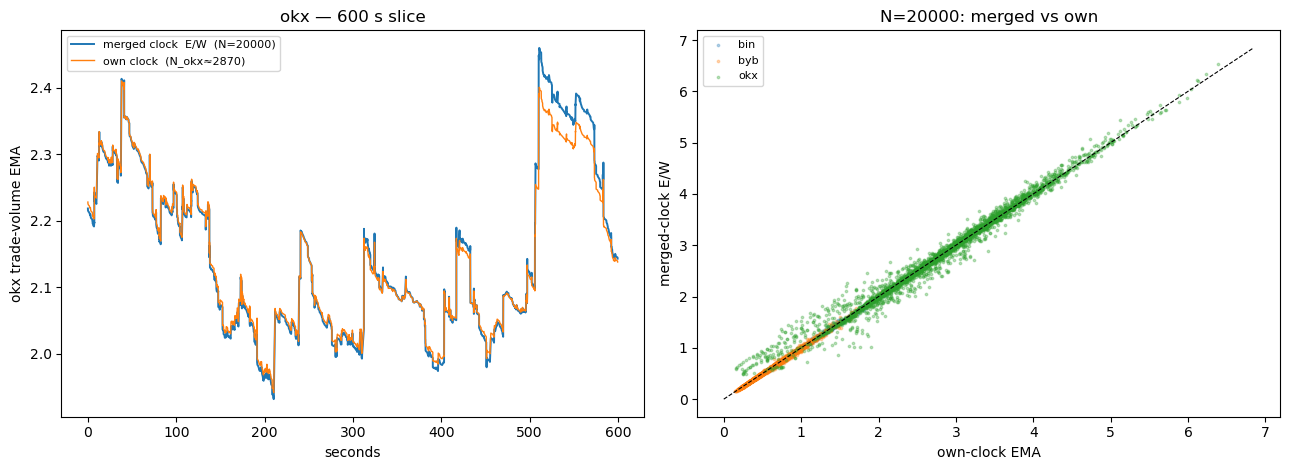

In [6]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.8))
t, vm, vo = overlay[20000]
t0 = t[0] + (t[-1] - t[0]) // 2
w = (t >= t0) & (t < t0 + 600_000_000_000)               # 600 s slice
ts = (t[w] - t[w][0]) / 1e9
axL.plot(ts, vm[w], lw=1.4, label="merged clock  E/W  (N=20000)")
axL.plot(ts, vo[w], lw=1.0, label="own clock  (N_okx≈2870)")
axL.set_xlabel("seconds"); axL.set_ylabel("okx trade-volume EMA"); axL.set_title("okx — 600 s slice")
axL.legend(fontsize=8)
for ex, c in zip(EX, ["C0", "C1", "C2"]):
    a, b = scatter[(20000, ex)]
    axR.scatter(b, a, s=3, alpha=0.3, color=c, label=ex)
lim = [0, max(axR.get_xlim()[1], axR.get_ylim()[1])]
axR.plot(lim, lim, "k--", lw=0.8)
axR.set_xlabel("own-clock EMA"); axR.set_ylabel("merged-clock E/W"); axR.set_title("N=20000: merged vs own")
axR.legend(fontsize=8); fig.tight_layout()

## Small N — where does the approximation fray?

The agreement loosens as N shrinks, and always more for the minority venue (fewer
of its own trades land in the window). This is the small-N under-sampling the
design flags — inherent to "the last N merged trades", not a defect of the EMA.

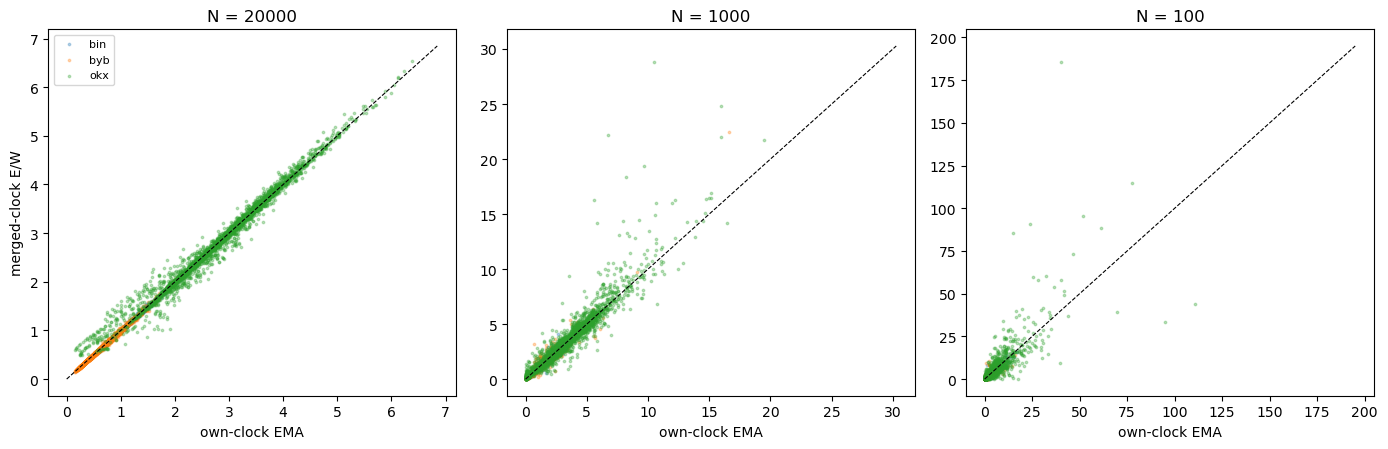

In [7]:
fig, axes = plt.subplots(1, len(NS), figsize=(14, 4.6))
for ax, N in zip(axes, NS):
    for ex, c in zip(EX, ["C0", "C1", "C2"]):
        a, b = scatter[(N, ex)]
        ax.scatter(b, a, s=3, alpha=0.3, color=c, label=ex)
    lim = [0, max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lim, lim, "k--", lw=0.8)
    ax.set_title(f"N = {N}"); ax.set_xlabel("own-clock EMA")
axes[0].set_ylabel("merged-clock E/W"); axes[0].legend(fontsize=8)
fig.tight_layout()

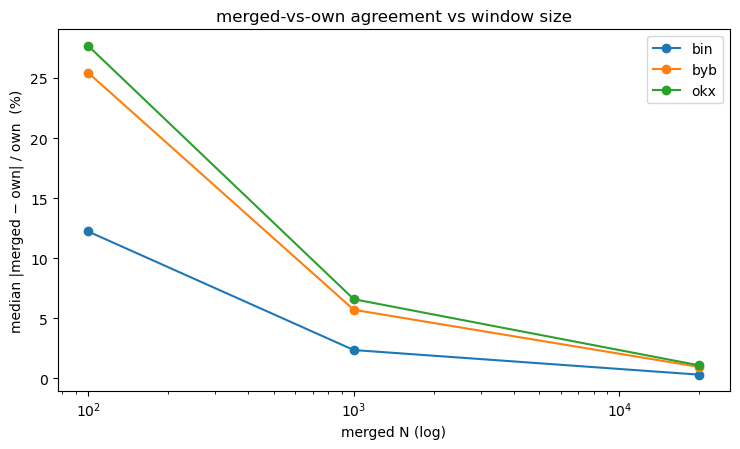

In [8]:
# agreement (median |rel diff|) vs N, per exchange
fig, ax = plt.subplots(figsize=(7.5, 4.6))
for ex, c in zip(EX, ["C0", "C1", "C2"]):
    d = res.filter(pl.col("exchange") == ex).sort("N")
    ax.plot(d["N"], d["med_rel_pct"], "o-", color=c, label=ex)
ax.set_xscale("log"); ax.set_xlabel("merged N (log)"); ax.set_ylabel("median |merged − own| / own  (%)")
ax.set_title("merged-vs-own agreement vs window size"); ax.legend(); fig.tight_layout()

## Read-out

**Validated at large N.** At N=20000 (≈280 s window) the merged-clock `E/W` and the
wall-clock-matched own-clock EMA agree to **0.3–1.1% median** (corr 0.99–1.00). So
the merged-clock per-exchange EMA *does* reproduce a clean own-clock EMA at the
matched scale, even though its per-exchange decay varies tick to tick — the
averaging over a large window makes the two weightings coincide. Agreement is
tightest for bin (60% of flow) and loosest for okx (14%), the sample-count order.

**Degrades predictably at small N.** 2–7% at N=1000, 12–28% at N=100, monotonically
in both N and (inversely) venue share. At N=100 an okx window holds only ~14 okx
trades, so the random merged-spacing of those few trades makes the two weightings
visibly diverge. This is exactly the minority-venue under-sampling from the design
doc — managed there by reading through `E/W` (+ small-W shrinkage) and exposing all
scales, not by abandoning the merged clock.

**Bottom line:** the merged trade clock is a faithful stand-in for per-exchange
event clocks at large N and an increasingly loose one at small N, in the precise,
predictable way the design anticipates.